# What the ML

**Découvrez comment le Machine Learning révolutionne notre façon de penser et de créer.**

## Introduction

Le Machine Learning (ou apprentissage automatique) est une composante essentielle de l'intelligence artificielle. Il permet aux machines d'apprendre à partir de données sans programmation explicite, en identifiant des motifs et en fournissant des prédictions précises.  Avant de commencer les projets pratiques, il est important de comprendre les notions clés suivantes.

### Import des librairies

In [ ]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# imports pour la validation croisée
import matplotlib.pylab as pla

import lightgbm as lgb

from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    GroupKFold,
    StratifiedGroupKFold,
)

# Configuration du style avec seaborn (méthode moderne)
sns.set_theme(style="white")

### Chargement des données

In [70]:
# data set apprentissage non supervisé
df_ul = pd.read_csv(r'C:\Users\Paul-Emmanuel Buffe\Desktop\la_plateforme\travaux_la_plateforme\what-is-machine-learning\data\force2020_data_unsupervised_learning.csv', index_col='DEPTH_MD')
# dataset Cross-Validation
df_cv = pd.read_csv(r'C:\Users\Paul-Emmanuel Buffe\Desktop\la_plateforme\travaux_la_plateforme\what-is-machine-learning\data\healthcare-dataset-stroke-data.csv')


### force2020_data_unsupervised_learning

In [71]:
df_ul.head()

,RHOB,GR,NPHI,PEF,DTC
DEPTH_MD,,,,,
494.528,1.884186,80.200851,NaN,20.915468,161.131180
494.680,1.889794,79.262886,NaN,19.383013,160.603470
494.832,1.896523,74.821999,NaN,22.591518,160.173615
494.984,1.891913,72.878922,NaN,32.191910,160.149429
495.136,1.880034,71.729141,NaN,38.495632,160.128342


### healthcare-dataset-stroke-data

In [72]:
df_cv.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Nettoyage et préparation des données

#### df_ul

In [73]:
# Nettoyage 
# df_ul
df_ul.dropna(inplace=True) # on ne considère pas les valeurs nullles
df_ul.describe()

,RHOB,GR,NPHI,PEF,DTC
count,12202.000000,12202.000000,12202.000000,12202.000000,12202.000000
mean,2.149947,61.253852,0.414572,3.912313,121.409905
std,0.251592,29.902708,0.139207,1.816933,30.394369
min,1.493417,6.191506,0.037976,1.126667,55.726753
25%,1.983767,42.792794,0.313797,2.629141,89.977041
50%,2.059335,62.886322,0.466891,3.365132,138.477173
75%,2.389839,77.726776,0.513840,4.686422,146.242302
max,2.889454,499.022583,0.800262,17.026619,163.910797


#### df_cv

In [74]:
def get_prep_data():

    # Conversion de ever_married en booléens (Yes/No → True/False)
    df_cv["ever_married"] = (
        df_cv["ever_married"].replace("Yes", True).replace("No", False)
    )
    
    # Conversion des colonnes textuelles en type category pour optimiser la mémoire
    df_cv["gender"] = df_cv["gender"].astype("category")
    df_cv["smoking_status"] = df_cv["smoking_status"].astype("category")
    df_cv["Residence_type"] = df_cv["Residence_type"].astype("category")
    df_cv["work_type"] = df_cv["work_type"].astype("category")
    
    # Ajout d'une colonne doctor avec valeurs aléatoires (0-7)
    df_cv["doctor"] = np.random.randint(0, 8, size=len(df_cv))

    
    # Sélection aléatoire de 500 échantillons pour l'ensemble de test
    holdout_ids = df_cv.sample(n=500, random_state=529).index

    # Création de l'ensemble d'entraînement (toutes les données sauf holdout)
    # Mélange aléatoire, tri par doctor, réinitialisation des index
    train = (
        df_cv.loc[~df_cv.index.isin(holdout_ids)]
        .sample(frac=1, random_state=529)
        .sort_values("doctor")
        .reset_index(drop=True)
    )
    
    # Création de l'ensemble de test (500 échantillons)
    # Mélange aléatoire, tri par doctor, réinitialisation des index
    holdout = (
        df_cv.loc[df_cv.index.isin(holdout_ids)]
        .sample(frac=1, random_state=529)
        .sort_values("doctor")
        .reset_index(drop=True)
    )

    return train, holdout


train, holdout = get_prep_data()

train.head()

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_22452\2072190295.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cv["ever_married"].replace("Yes", True).replace("No", False)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,doctor
0,46438,Female,54.0,0,0,True,Self-employed,Urban,79.30,30.6,formerly smoked,0,0
1,72642,Male,67.0,0,0,True,Govt_job,Urban,67.79,26.0,formerly smoked,0,0
2,28227,Female,27.0,0,0,True,Private,Urban,71.50,40.3,smokes,0,0
3,41600,Male,52.0,0,0,True,Private,Rural,67.92,31.1,never smoked,0,0
4,17569,Male,41.0,0,0,True,Self-employed,Rural,93.52,31.5,Unknown,0,0


## I. La science des données

## 1. Définition et Fondements


- C'est un domaine multidisciplinaire fusionnant les mathématiques, les statistiques, l'informatique (programmation), l'analytique avancée et l'Intelligence Artificielle (IA).
- Son but est d'analyser des volumes massifs de données brutes (Big Data), qu'elles soient structurées (bases SQL, tableurs) ou non structurées (textes, images, audio, journaux serveurs).
- L'objectif ultime est d'extraire des modèles cachés (*patterns*) et des informations exploitables (*actionable insights*) afin de comprendre le passé, anticiper l'avenir et guider la prise de décision stratégique.


---


## 2. Le cycle de vie d'un projet (Pipeline de la donnée)


> La modélisation n'est qu'une étape d'un processus itératif rigoureux. 
> **La DataViz intervient à deux niveaux cruciaux : exploration analytique puis communication stratégique.**


- **A. L'ingestion (Collecte)** : récupération des données depuis de multiples sources (API, web scraping, capteurs IoT, streaming). 
- **B. Le stockage et le traitement** : intégration dans des *Data Lakes* ou *Data Warehouses* via des processus ETL (Extraction, Transformation, Chargement). 
- **C. Le nettoyage (Data Wrangling)** : étape généralement la plus chronophage dans un projet de Data Science. Traitement des valeurs manquantes (`df.dropna()`), doublons, normalisation et optimisation de la mémoire. 
- **D. L'analyse exploratoire (EDA)** : premier niveau de DataViz (`matplotlib`, `seaborn`) et statistiques descriptives pour comprendre la distribution des variables, détecter des anomalies et identifier d’éventuels biais. 
- **E. La modélisation** : création, entraînement et optimisation de modèles d’apprentissage automatique. 
- **F. L’évaluation, le déploiement et la BI** : évaluation des performances avec des métriques adaptées, mise en production du modèle (MLOps) et second niveau de DataViz via des tableaux de bord interactifs (Business Intelligence) pour communication aux décideurs.


---


## 3. L'Écosystème : Rôles et Outils


La Data Science est un travail collaboratif s'appuyant sur le Cloud Computing (scalabilité, élasticité et puissance de calcul GPU).


- **Le Data Engineer** : conçoit l’infrastructure, les bases de données et les pipelines de données (ETL). 
- **Le Data Analyst** : analyse les données historiques et crée des tableaux de bord (BI). 
- **Le Data Scientist** : utilise Python, R ou SQL (souvent via des *Jupyter Notebooks*) pour développer des modèles prédictifs et prescriptifs basés sur le Machine Learning ou le Deep Learning.


---


## 4. Applications et Défis


**Applications :**


- Détection de fraudes (finance) 
- Moteurs de recommandation (e-commerce) 
- Maintenance prédictive (industrie) 


**Défis :**


- Qualité des données ("Garbage In, Garbage Out") 
- Biais algorithmiques et enjeux éthiques 
- Interprétabilité des modèles 
- Déploiement et maintien en production (MLOps), notamment face à la dérive des données (*Data Drift*) et à la dérive du concept (*Concept Drift*)

## II. L’apprentissage automatique et/ou l’apprentissage profond

## 1. Hiérarchie et branches de l'IA


- **Intelligence Artificielle (IA)** : domaine global visant à reproduire certaines capacités cognitives humaines. 
- **Machine Learning (ML)** : sous-ensemble de l’IA regroupant des algorithmes capables d’apprendre à partir de données en minimisant une fonction de perte. Il se divise en quatre grands paradigmes : 
 1. *Apprentissage supervisé* (données étiquetées) 
 2. *Apprentissage non supervisé* (clustering, réduction de dimension) 
 3. *Apprentissage semi-supervisé* 
 4. *Apprentissage par renforcement* (système de récompense/punition) 
- **Deep Learning (DL)** : sous-ensemble du ML reposant sur des réseaux de neurones multicouches capables d’apprendre des représentations complexes des données.


---


## 2. Machine Learning vs Deep Learning : différences fondamentales


**Ingénierie des caractéristiques :**


- **ML** : l’humain conçoit et sélectionne manuellement les caractéristiques pertinentes (*Feature Engineering*). 
- **DL** : le modèle apprend automatiquement des représentations internes (*Feature Extraction*) à partir des données brutes grâce aux couches cachées.


**Volume et typologie de données :** 
Le Deep Learning exploite particulièrement bien les très grands volumes de données **non structurées** (images, texte, audio). 
Les modèles de ML classiques (notamment les algorithmes de boosting comme *LightGBM* ou *XGBoost*) restent souvent plus efficaces sur des données **structurées (tabulaires)**.


**Temps d'exécution :** 


- **ML** : entraînement rapide, inférence rapide. 
- **DL** : entraînement long nécessitant des GPU/TPU, inférence rapide une fois optimisé.


---


## 3. Applications concrètes


**Machine Learning :**


- Score de crédit 
- Prédiction d’attrition client (churn) 
- Modélisation tabulaire 


**Deep Learning :**


- Vision par ordinateur (véhicules autonomes) 
- Traitement automatique du langage naturel (LLM comme ChatGPT) 
- Reconnaissance vocale 


## III. L’apprentissage supervisé

## 1. Définition et fonctionnement


- Méthode où l'algorithme apprend sur des données **étiquetées**. On lui fournit les variables explicatives (*Features* – $X$) ainsi que la variable cible (*Target* – $y$). 
- **Processus itératif :** le modèle prédit, calcule son erreur via une fonction de perte, puis ajuste ses paramètres pour optimiser sa généralisation.


---


## 2. Les deux grandes familles


### Classification


Prédit une catégorie discrète (ex : 1/0 pour un AVC). 


**Algorithmes :** 


- Régression logistique 
- Random Forest 
- Gradient Boosting (LightGBM, XGBoost) 
- SVM 
- KNN 
- Naïve Bayes 


### Régression


Prédit une valeur numérique continue (ex : chiffre d'affaires). 


**Algorithmes :** 


- Régression linéaire 
- Régression polynomiale 
- Ridge 
- Lasso 
- Arbres de régression 


## IV. L'Apprentissage Non Supervisé

### Introduction

L'apprentissage non supervisé est une branche du machine learning qui permet d'analyser et de structurer des données sans étiquetage préalable. Cette approche est particulièrement utile pour découvrir des structures cachées dans de grandes quantités de données. Les modèles d'apprentissage non supervisé sont employés pour trois tâches principales : **le clustering (partitionnement)**, **l'association** et **la réduction de la dimensionnalité**.

---

### 1. Le Partitionnement (Clustering)

Le partitionnement regroupe des données non étiquetées selon leurs similitudes ou différences. Cette technique transforme des objets de données bruts en structures organisées représentant l'information sous-jacente.

#### A. Partitionnement Exclusif : K-moyennes

Le partitionnement en **K-moyennes** affecte chaque point de données à l'un des K groupes prédéfinis. Les points sont assignés au cluster dont le centroïde (centre) est le plus proche. Les données les plus proches d'un même centroïde forment ainsi une catégorie homogène.

#### B. Partitionnement Hiérarchique

Le partitionnement hiérarchique se décline en deux approches :

**Approche agglomérative (ascendante)** : Chaque point de données commence dans un cluster distinct, puis les clusters similaires fusionnent progressivement jusqu'à n'en former qu'un seul. La distance euclidienne mesure généralement la similarité via quatre méthodes :
- **Liaison de Ward** : basée sur l'augmentation de la somme des carrés après fusion
- **Liaison moyenne** : distance moyenne entre tous les points de deux clusters
- **Liaison complète** : distance maximale entre deux points de clusters différents
- **Liaison simple** : distance minimale entre deux points de clusters différents

**Approche divisive (descendante)** : Un seul cluster initial est progressivement divisé selon les différences entre points. Cette méthode est moins couramment utilisée.

#### C. Partitionnement Probabiliste

Cette approche regroupe les points selon la **probabilité** qu'ils appartiennent à une distribution particulière. Le **Modèle de Mélange Gaussien (GMM)** est la méthode probabiliste la plus répandue, permettant un partitionnement "doux" où un point peut appartenir partiellement à plusieurs clusters.

---

### 2. Les Règles d'Association

Les règles d'association identifient des relations entre variables dans un jeu de données.

#### Algorithmes Apriori

Issus de l'analyse de panier d'achat, les algorithmes Apriori alimentent aujourd'hui les moteurs de recommandation. Ils identifient des ensembles d'éléments fréquemment associés pour prédire la consommation d'un produit en fonction d'un autre.

**Exemple concret** : Sur Spotify, écouter Black Sabbath déclenche des recommandations de Led Zeppelin, basées sur les habitudes d'écoute personnelles et collectives. Ces algorithmes utilisent un arbre de hachage pour analyser exhaustivement les données transactionnelles.

---

### 3. La Réduction de la Dimensionnalité

Bien que davantage de données améliorent généralement la précision, elles peuvent provoquer du surajustement et compliquer la visualisation. La **réduction de la dimensionnalité** diminue le nombre de caractéristiques tout en préservant l'intégrité des données. Cette étape de prétraitement est essentielle pour gérer des données complexes.

#### A. Analyse en Composantes Principales (ACP)

L'ACP simplifie des données complexes en créant de nouvelles variables synthétiques appelées "composantes principales".

**Principe** : La première composante capture la direction de variance maximale. La deuxième composante cherche aussi la variance maximale, mais dans une direction perpendiculaire à la première. Ce processus se répète, chaque nouvelle composante étant orthogonale aux précédentes. Résultat : l'information essentielle est conservée avec moins de dimensions.

#### B. Décomposition en Valeurs Singulières (SVD)

La SVD factorise une matrice complexe A en trois matrices plus simples (A = USVT), où U et V sont des matrices orthogonales et S est une matrice diagonale contenant les valeurs singulières. Comme l'ACP, elle sert à réduire le bruit et compresser les données, notamment les fichiers image.

#### C. Auto-encodeurs

Les auto-encodeurs utilisent des réseaux de neurones pour compresser puis reconstruire les données. La **couche cachée** agit comme un goulet d'étranglement : elle compresse l'information (phase d'**encodage**) avant de la reconstruire dans la couche de sortie (phase de **décodage**).

---

### 4. Applications Concrètes

L'apprentissage non supervisé améliore l'expérience utilisateur et identifie rapidement des modèles dans de grandes quantités de données :

- **Rubriques d'actualités** : Google Actualités regroupe automatiquement des articles similaires provenant de sources différentes
- **Vision par ordinateur** : reconnaissance d'objets dans les images
- **Imagerie médicale** : détection, classification et segmentation d'images pour des diagnostics rapides et précis
- **Détection d'anomalies** : identification de données atypiques révélant des équipements défectueux, erreurs humaines ou failles de sécurité
- **Profils clients** : identification des traits communs et habitudes d'achat pour personnaliser les messages marketing
- **Moteurs de recommandation** : analyse des comportements de consommation pour suggérer des produits complémentaires pertinents

---

### 5. Les Défis de l'Apprentissage Non Supervisé

Malgré ses avantages, cette approche présente plusieurs limitations :

- **Complexité informatique** due au volume élevé des données d'entraînement
- **Temps d'entraînement prolongés**
- **Risque accru de résultats inexacts**
- **Intervention humaine nécessaire** pour valider les variables de sortie
- **Manque de transparence** quant aux critères de regroupement des données



#### Implémentation Kmeans avec Python
**Standardisation**

In [75]:
scaler= StandardScaler()

In [76]:
# Standardisation df_ul
df_ul[['RHOB_T','NPHI_T', 'GR_T', 'PEF_T', 'DTF_T']] = scaler.fit_transform(df_ul[['RHOB', 'NPHI', 'GR', 'PEF', 'DTC']])
df_ul

,RHOB,GR,NPHI,PEF,DTC,RHOB_T,NPHI_T,GR_T,PEF_T,DTF_T
DEPTH_MD,,,,,,,,,,
1138.704,1.774626,55.892757,0.765867,1.631495,147.837677,-1.491843,2.523654,-0.179292,-1.255364,0.869531
1138.856,1.800986,60.929138,0.800262,1.645080,142.382431,-1.387067,2.770744,-0.010859,-1.247886,0.690042
1139.008,1.817696,62.117264,0.765957,1.645873,138.258331,-1.320646,2.524300,0.028875,-1.247450,0.554350
1139.160,1.829333,61.010860,0.702521,1.620216,139.198914,-1.274390,2.068584,-0.008126,-1.261572,0.585297
1139.312,1.813854,58.501236,0.639708,1.504854,144.290085,-1.335919,1.617342,-0.092056,-1.325067,0.752808
...,...,...,...,...,...,...,...,...,...,...
2993.256,2.468236,90.537521,0.341534,4.699200,86.474564,1.265151,-0.524699,0.979338,0.433103,-1.149449
2993.408,2.457519,88.819122,0.351085,4.699200,86.187599,1.222550,-0.456081,0.921870,0.433103,-1.158891
2993.560,2.429228,92.128922,0.364982,4.699200,87.797836,1.110101,-0.356250,1.032560,0.433103,-1.105910


**Indentification du bon nombre de clusters: Méthode Elbow**:
- Dans un contexte d’apprentissage non supervisé, le nombre optimal de clusters n’est pas connu à l’avance. La méthode du coude permet d’estimer ce nombre en évaluant l’inertie du modèle K-means pour différentes valeurs de K.

In [77]:
# Création de la fonction
# Pour k nombre de clusters
# Inertie (K-means) Somme des distances au carré entre chaque point et le centroïde de son cluster
# => Plus l’inertie est faible, plus les clusters sont compacts

def optimise_k_means(data, max_k):
    moyenne = []
    inertias = []

    for k in range(1, max_k):

        # On instancie un algorithme de clustering non supervisé :
        kmeans = KMeans(n_clusters=k)

        # K-means : initialise des centroïdes, assigne les points au plus proche,
        # met à jour les centres et itère jusqu'à convergence
        kmeans.fit(data)

        moyenne.append(k)
        inertias.append(kmeans.inertia_)
    
    # Génération du Elbow plot
    fig = plt.subplots(figsize=(10, 5))
    plt.plot(moyenne, inertias, 'o-')
    plt.xlabel('Nombre de Clusters')
    plt.ylabel('Inertie')
    plt.grid(True)
    plt.show()

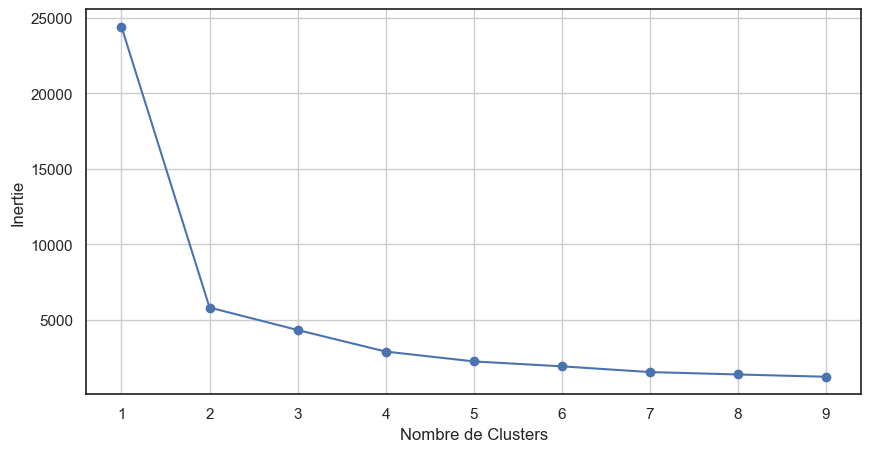

In [78]:
optimise_k_means(df_ul[['RHOB_T', 'NPHI_T']], 10)

**Application de l'algo K Means**

In [79]:
# Algo KMeans avec le nombre de clusters choisi
kmeans = KMeans(n_clusters=3)

In [80]:
# Application sur les colonnes choisies de notre dataset
kmeans.fit(df_ul[['NPHI_T', 'RHOB_T']])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Le paramètre `n_clusters` définit le nombre de groupes à former. En apprentissage non supervisé, cette valeur n’est pas connue à l’avance et doit être estimée, par exemple à l’aide de la méthode Elbow.

Le paramètre `init='k-means++'` détermine la manière dont les centroïdes sont initialisés. Cette méthode permet de placer les centres de manière intelligente afin d’améliorer la convergence et la qualité du clustering.

Le paramètre `n_init` correspond au nombre de lancements de l’algorithme avec différentes initialisations. Le meilleur résultat est conservé, ce qui réduit l’impact du hasard et évite les minima locaux.

Le paramètre `max_iter` fixe le nombre maximal d’itérations autorisées. Il garantit que l’algorithme s’arrête même si la convergence n’est pas atteinte rapidement.

Le paramètre `random_state` permet de fixer la graine aléatoire afin d’obtenir des résultats reproductibles.


In [81]:
# Ajout d'une colonne supplémentaire à notre data set pour 
# lier chaque id à son cluster le plus proche

df_ul['kmeans_3'] = kmeans.labels_
df_ul

,RHOB,GR,NPHI,PEF,DTC,RHOB_T,NPHI_T,GR_T,PEF_T,DTF_T,kmeans_3
DEPTH_MD,,,,,,,,,,,
1138.704,1.774626,55.892757,0.765867,1.631495,147.837677,-1.491843,2.523654,-0.179292,-1.255364,0.869531,0
1138.856,1.800986,60.929138,0.800262,1.645080,142.382431,-1.387067,2.770744,-0.010859,-1.247886,0.690042,0
1139.008,1.817696,62.117264,0.765957,1.645873,138.258331,-1.320646,2.524300,0.028875,-1.247450,0.554350,0
1139.160,1.829333,61.010860,0.702521,1.620216,139.198914,-1.274390,2.068584,-0.008126,-1.261572,0.585297,0
1139.312,1.813854,58.501236,0.639708,1.504854,144.290085,-1.335919,1.617342,-0.092056,-1.325067,0.752808,0
...,...,...,...,...,...,...,...,...,...,...,...
2993.256,2.468236,90.537521,0.341534,4.699200,86.474564,1.265151,-0.524699,0.979338,0.433103,-1.149449,2
2993.408,2.457519,88.819122,0.351085,4.699200,86.187599,1.222550,-0.456081,0.921870,0.433103,-1.158891,2
2993.560,2.429228,92.128922,0.364982,4.699200,87.797836,1.110101,-0.356250,1.032560,0.433103,-1.105910,2


**Visualisation des résultats**

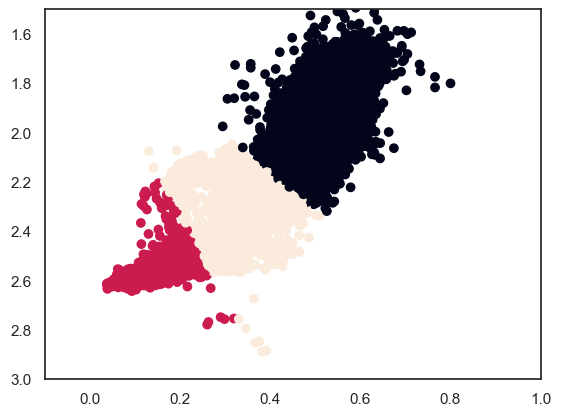

In [82]:
plt.scatter(x=df_ul['NPHI'], y=df_ul['RHOB'], c=df_ul['kmeans_3'])
plt.xlim(-0.1, 1)
plt.ylim(3, 1.5)
plt.show()

**Augmentation du nombre de clusters**

In [83]:
for k in range(1, 11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(df_ul[['RHOB_T', 'NPHI_T']])
    df_ul[f'KMeans_{k}'] = kmeans.labels_

df_ul

,RHOB,GR,NPHI,PEF,DTC,RHOB_T,NPHI_T,GR_T,PEF_T,DTF_T,...,KMeans_1,KMeans_2,KMeans_3,KMeans_4,KMeans_5,KMeans_6,KMeans_7,KMeans_8,KMeans_9,KMeans_10
DEPTH_MD,,,,,,,,,,,,,,,,,,,,,
1138.704,1.774626,55.892757,0.765867,1.631495,147.837677,-1.491843,2.523654,-0.179292,-1.255364,0.869531,...,0,0,0,0,3,0,4,4,8,6
1138.856,1.800986,60.929138,0.800262,1.645080,142.382431,-1.387067,2.770744,-0.010859,-1.247886,0.690042,...,0,0,0,0,3,0,4,4,8,6
1139.008,1.817696,62.117264,0.765957,1.645873,138.258331,-1.320646,2.524300,0.028875,-1.247450,0.554350,...,0,0,0,0,3,0,4,4,8,6
1139.160,1.829333,61.010860,0.702521,1.620216,139.198914,-1.274390,2.068584,-0.008126,-1.261572,0.585297,...,0,0,0,0,3,0,4,4,8,6
1139.312,1.813854,58.501236,0.639708,1.504854,144.290085,-1.335919,1.617342,-0.092056,-1.325067,0.752808,...,0,0,0,0,3,0,4,4,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993.256,2.468236,90.537521,0.341534,4.699200,86.474564,1.265151,-0.524699,0.979338,0.433103,-1.149449,...,0,1,1,1,1,4,3,3,2,0
2993.408,2.457519,88.819122,0.351085,4.699200,86.187599,1.222550,-0.456081,0.921870,0.433103,-1.158891,...,0,1,1,1,1,4,3,3,2,0
2993.560,2.429228,92.128922,0.364982,4.699200,87.797836,1.110101,-0.356250,1.032560,0.433103,-1.105910,...,0,1,1,1,1,4,3,3,2,4


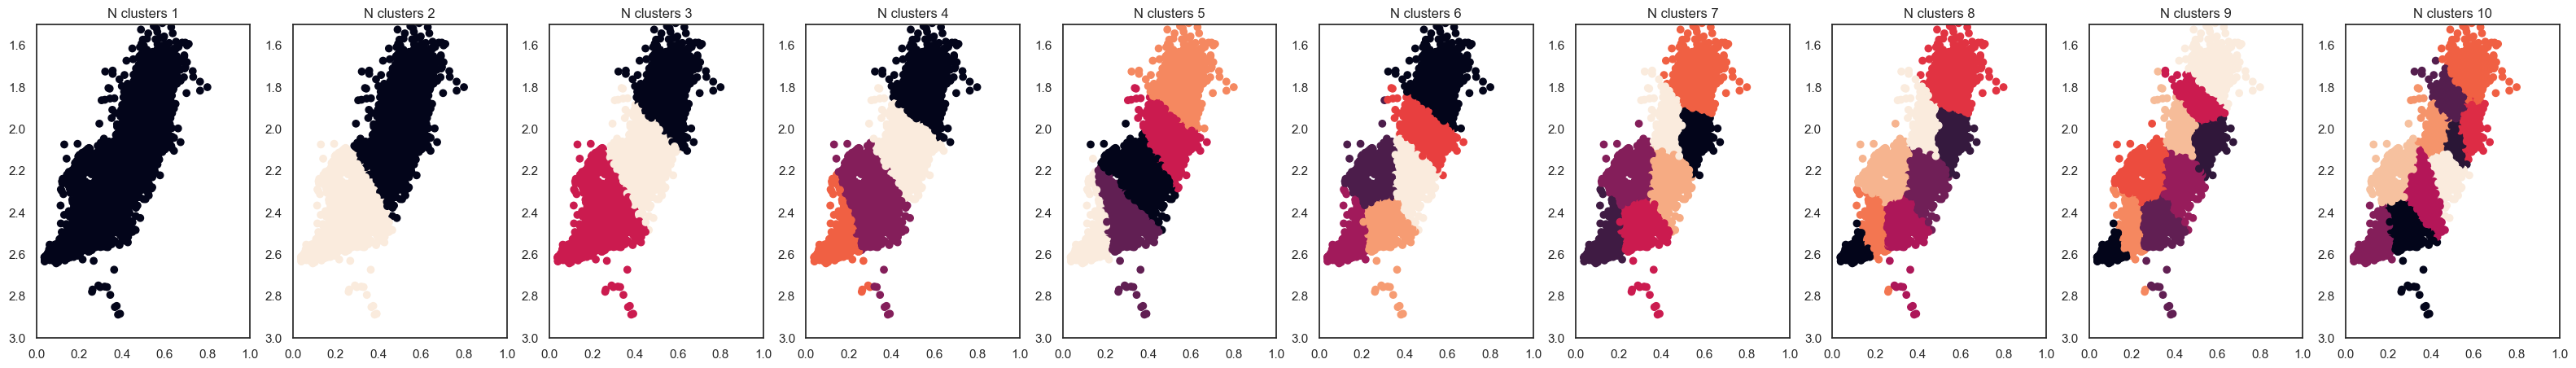

In [84]:
fig, axs = plt.subplots(nrows=1, ncols=10, figsize=(40, 5))

for i, ax in enumerate(fig.axes, start=1):
    ax.scatter(x=df_ul['NPHI'], y=df_ul['RHOB'], c=df_ul[f'KMeans_{i}'])
    ax.set_ylim(3, 1.5)
    ax.set_xlim(0, 1)
    ax.set_title(f'N clusters {i}')


---

### Conclusion

L'apprentissage non supervisé offre des outils puissants pour explorer et structurer de grandes quantités de données sans étiquetage préalable. Du partitionnement à la réduction de dimensionnalité, ces techniques transforment des données brutes en informations exploitables, avec des applications concrètes dans de nombreux domaines. Toutefois, leur mise en œuvre requiert une validation rigoureuse et une compréhension approfondie de leurs limites.

## E. La classification supervisée



### Définition
La **classification supervisée** est une méthode d’apprentissage automatique (*machine learning*) qui consiste à **prédire une classe ou une catégorie** à laquelle appartient une observation à partir de données **étiquetées**.  
Chaque donnée est décrite par un ensemble de **variables explicatives (features)** et une **variable cible (label)** connue à l’avance.  
Le modèle apprend une fonction de décision capable de **généraliser** sur de nouvelles données.



### Objectifs de la classification supervisée
Les principaux objectifs sont :
- Attribuer une **classe** à de nouvelles observations
- Automatiser la **prise de décision**
- Identifier des **relations et patterns** entre variables
- Améliorer la **performance prédictive**

**Exemples d’applications :**
- Détection de spam
- Diagnostic médical
- Prédiction de churn client
- Classification d’images ou de textes



### Fondements de la méthode
La classification supervisée repose sur plusieurs principes clés :

1. **Données étiquetées**  
   Le modèle apprend à partir d’un jeu de données contenant des couples *(X, y)*.

2. **Fonction de décision**  
   Le modèle cherche une fonction \( f(X) = y \) qui sépare les classes.

3. **Frontière de décision**  
   Limite mathématique qui sépare les différentes classes dans l’espace des variables.

4. **Généralisation**  
   Capacité du modèle à bien prédire sur des données inconnues.


### Algorithmes de classification supervisée (version simplifiée)

#### Régression logistique
**Principe :**
La régression logistique sert à répondre à une question du type :  
 "Oui ou Non ?" / "Vrai ou Faux ?"  

Elle calcule la probabilité qu’un élément appartienne à une catégorie.  
Par exemple : "Quelle est la probabilité que cet email soit un spam ?"

**Avantages :**  
- Facile à comprendre  
- Les résultats sont simples à interpréter  

**Limites :**  
- Moins efficace si les relations entre les données sont complexes  



#### k-Nearest Neighbors (k-NN)
**Principe :**
Cet algorithme fonctionne par comparaison.  
Il regarde les **k éléments les plus proches** d’un nouveau point et choisit la catégorie la plus fréquente parmi eux.  

 En gros : "Dis-moi qui sont tes voisins, je te dirai qui tu es."

**Avantages :**  
- Très intuitif  
- Simple à mettre en place  

**Limites :**  
- Peut être lent si on a beaucoup de données  
- Sensible aux données aberrantes  



#### Arbre de décision
**Principe :**
Il fonctionne comme un **jeu de questions-réponses**.  

Exemple :  
- Est-ce que l’âge > 30 ?  
  - Oui → Question suivante  
  - Non → Autre branche  

Il prend une décision en suivant une série de règles simples.

**Avantages :**  
- Très facile à comprendre  
- Visuel et logique  

**Limites :**  
- Peut apprendre "trop par cœur" les données (surapprentissage)  



#### Forêt aléatoire (Random Forest)
**Principe :**
Au lieu d’un seul arbre de décision, on en crée **plusieurs**.  
Chaque arbre donne son avis, puis on prend la décision majoritaire.  

 C’est comme demander l’avis à plusieurs experts au lieu d’un seul.

**Avantages :**  
- Plus fiable qu’un seul arbre  
- Généralement plus performant  

**Limites :**  
- Plus difficile à expliquer précisément  



#### Support Vector Machine (SVM)
**Principe :**
Cet algorithme cherche à tracer **la meilleure ligne (ou frontière)** qui sépare les catégories.  

 Il essaie de séparer les groupes le plus clairement possible.

**Avantages :**  
- Très efficace quand les données sont nombreuses ou complexes  

**Limites :**  
- Réglage parfois compliqué  
- Moins intuitif à comprendre  



#### Réseaux de neurones artificiels
**Principe :**
Inspirés du cerveau humain, ils sont composés de plusieurs couches qui transforment progressivement l’information pour prendre une décision.  

 Ils apprennent en corrigeant leurs erreurs petit à petit.

**Avantages :**  
- Très puissants pour les problèmes complexes (images, texte, voix)  

**Limites :**  
- Fonctionnement difficile à expliquer  
- Nécessitent beaucoup de données et de calcul  


### Interprétation des résultats
L’interprétation dépend du type de modèle :

- **Modèles interprétables**  
  - Régression logistique  
  - Arbres de décision  
  → Analyse des coefficients, règles ou variables importantes

- **Modèles complexes**  
  - SVM  
  - Réseaux de neurones  
  → Interprétation via probabilités, importance des variables ou méthodes explicatives

Les résultats peuvent être analysés à l’aide :
- des probabilités de classe
- des erreurs de classification
- des matrices de confusion

---

### Validation des résultats
La validation permet d’évaluer la fiabilité du modèle.

### Méthodes de validation
- Séparation **jeu d’entraînement / jeu de test**
- **Validation croisée (cross-validation)**

### Indicateurs de performance
- Accuracy
- Précision
- Rappel (Recall)
- F1-score
- Matrice de confusion
- Courbe ROC et AUC




### Conclusion
La classification supervisée est une **méthode fondamentale en data science et en intelligence artificielle**.  
Le choix de l’algorithme dépend :
- du volume de données
- de la complexité du problème
- du besoin d’interprétabilité
- des contraintes métiers



## F. La Classification Non Supervisée

### Introduction

La classification non supervisée constitue le principal résultat analytique de l'apprentissage non supervisé présenté en section D. Là où D. décrit les méthodes (clustering, association, réduction de dimensionnalité), F. se concentre sur l'objectif analytique : organiser les données en catégories homogènes révélant leur structure interne.

La classification non supervisée désigne donc le processus de construction de classes à partir de données non étiquetées, indépendamment de tout objectif prédictif explicite.

---

### I. Objectifs de la Classification Non Supervisée

La classification non supervisée vise principalement à :

- structurer un ensemble de données complexes ou volumineuses ;
- identifier des profils ou comportements similaires ;
- révéler des régularités ou des patterns latents ;
- fournir une base analytique à des décisions métier ou à des analyses ultérieures.

Elle s'inscrit dans une démarche exploratoire et descriptive, sans finalité prédictive directe.

---

### II. Fondements Méthodologiques

La classification non supervisée repose sur trois éléments essentiels :

- la sélection et la préparation des variables décrivant les individus ;
- le choix d'une mesure de similarité ou de distance ;
- une règle de regroupement permettant d'affecter les observations à des classes.

Les classes sont construites de manière à maximiser l'homogénéité interne tout en assurant une différenciation claire entre les groupes.

---

### III. Caractère Non Unique de la Classification

Pour un même jeu de données, plusieurs classifications non supervisées peuvent être produites. Les résultats dépendent fortement :

- des variables retenues et de leur transformation ;
- des méthodes de normalisation appliquées ;
- des paramètres et hypothèses propres aux algorithmes utilisés.

Il n'existe donc pas de classification unique ou universelle, mais différentes représentations possibles de la structure des données.

---

### IV. Interprétation et Validation des Classes

En l'absence de classes de référence, l'interprétation constitue une étape centrale du processus. Elle implique :

- l'analyse des caractéristiques dominantes de chaque classe ;
- la comparaison des classes entre elles ;
- la validation de leur cohérence au regard du contexte d'étude.

Cette phase introduit une supervision humaine a posteriori, indispensable pour donner du sens aux résultats obtenus.

---

### V. Rôle dans un Pipeline Data

La classification non supervisée est fréquemment utilisée comme :

- étape exploratoire initiale ;
- outil de segmentation descriptive ;
- support à la création de variables synthétiques ;
- aide à la prise de décision stratégique.

Elle s'intègre généralement en amont d'analyses statistiques avancées ou de modèles supervisés.

---

### Conclusion

La classification non supervisée constitue un levier essentiel de l'analyse exploratoire des données. En structurant l'information sans référence préalable, elle permet de mieux comprendre des ensembles de données complexes. Toutefois, son efficacité repose sur des choix méthodologiques rigoureux et sur la capacité de l'analyste à interpréter et valider les classes produites.

## G. La Régression

### Définition

La **régression** est une méthode d'apprentissage supervisé utilisée pour **prédire une valeur numérique continue** à partir de données d'entrée. Contrairement à la classification qui prédit une catégorie (oui/non, spam/non spam), la régression prédit une **quantité mesurable**.

**Exemples :** prédire le prix d'une maison, estimer le salaire d'un individu, prévoir la température de demain, estimer les ventes d'un produit.

---

### Objectifs

Les principaux objectifs sont :

- modéliser la relation entre une ou plusieurs variables explicatives (X) et une variable cible (Y) ;
- prédire une valeur numérique pour de nouvelles données ;
- comprendre l'impact des variables sur le phénomène étudié ;
- aider à la prise de décision basée sur des données.

---

### Fondements de la méthode

#### Relation entre variables

On suppose qu'il existe une relation entre les variables explicatives (X) et la variable cible (Y). La régression cherche une fonction $Y = f(X)$, qui peut être linéaire (droite) ou non linéaire (courbe).

#### Types de régression

**Régression linéaire simple** : une seule variable explicative, relation représentée par une droite.
Exemple : Prix = a × Surface + b

**Régression linéaire multiple** : plusieurs variables explicatives, relation toujours linéaire.
Exemple : Prix = a × Surface + b × Localisation + c × Nombre de pièces

**Régression polynomiale** : relation non linéaire, utilise des puissances des variables (X², X³…).

**Régression Ridge** : variante de la régression linéaire avec pénalité pour éviter des coefficients trop grands, réduit le risque de surapprentissage.

**Régression Lasso** : similaire à Ridge, peut annuler certains coefficients et permet la sélection de variables.

**Régression Elastic Net** : combine Ridge et Lasso, bon compromis quand il y a beaucoup de variables corrélées.

**Régression logistique** : malgré son nom, elle sert à la **classification binaire** et non à prédire une valeur continue. Elle estime la probabilité d'appartenance à une classe.

#### Minimisation de l'erreur

Le modèle ajuste ses paramètres pour réduire l'écart entre les valeurs réelles et les valeurs prédites. C'est la **minimisation de la fonction de coût** (souvent l'erreur quadratique moyenne).

#### Hypothèses (régression linéaire)

- Relation linéaire entre X et Y
- Indépendance des erreurs
- Homoscédasticité (variance constante des erreurs)
- Distribution normale des erreurs (dans certains contextes)

---

### Interprétation des résultats

**Coefficients** : dans une régression linéaire, chaque coefficient indique l'impact d'une variable sur la variable cible. Exemple : si le coefficient de la surface = 2000, chaque m² supplémentaire augmente le prix de 2000€.

**Intercept** : valeur prédite lorsque toutes les variables explicatives sont égales à 0.

**Importance des variables** : permet d'identifier les variables les plus influentes et celles peu pertinentes.

**Analyse des résidus** : les résidus (différences entre valeur réelle et valeur prédite) permettent d'analyser la qualité du modèle, la présence d'anomalies et un éventuel biais.

---

### Validation et indicateurs de performance

On divise généralement les données en jeu d'entraînement et jeu de test, ou on utilise la validation croisée.

Les indicateurs courants sont :

- **MSE** (Mean Squared Error) : moyenne des carrés des erreurs
- **RMSE** (Root Mean Squared Error) : racine carrée du MSE, exprimée dans la même unité que la variable cible
- **MAE** (Mean Absolute Error) : moyenne des erreurs absolues, moins sensible aux grandes erreurs
- **R²** (coefficient de détermination) : proportion de variance expliquée par le modèle (1 = parfait, proche de 0 = peu explicatif)

---

### Conclusion

La régression est une méthode essentielle en data science pour prédire des valeurs numériques continues et analyser les relations entre variables. Elle permet de comprendre les phénomènes, d'anticiper des évolutions et d'aider à la prise de décision stratégique. Le choix du modèle dépend de la nature des données, de la complexité de la relation, du besoin d'interprétabilité et des contraintes métier.

## I. Les données d'entraînement, les données de test et/ou de validation

### Introduction

En apprentissage automatique, les **données** sont la base de tout modèle. Un jeu de données est généralement composé de :

- **Variables explicatives (X)** : les caractéristiques utilisées pour faire une prédiction
- **Variable cible (y)** : la valeur à prédire (catégorie ou valeur numérique)

La qualité du modèle dépend fortement de la qualité des données, de leur quantité, de leur diversité et de leur représentativité.

---

### Les données d'entraînement (Training Set)

Les **données d'entraînement** servent à apprendre au modèle comment relier X à y. C'est sur ces données que le modèle ajuste ses paramètres, minimise son erreur et apprend les relations. Elles représentent en général 70 à 80 % du dataset total.

### Les données de validation (Validation Set)

Les **données de validation** servent à évaluer le modèle pendant la phase d'entraînement. Elles permettent d'ajuster les hyperparamètres, de comparer plusieurs modèles et de détecter le surapprentissage. Elles représentent souvent 10 à 15 % du dataset.

### Les données de test (Test Set)

Les **données de test** servent à évaluer les performances finales du modèle. Elles ne sont jamais utilisées pendant l'apprentissage et ne servent pas au réglage des paramètres. Elles représentent généralement 10 à 20 % du dataset.

---

### Pourquoi diviser les données ?

**Éviter le surapprentissage (Overfitting)** : un modèle peut apprendre parfaitement les données d'entraînement mais échouer sur de nouvelles données. Sans séparation, on risque de croire que le modèle est performant alors qu'il a simplement mémorisé les données.

**Tester la capacité de généralisation** : le but du machine learning est de bien prédire sur des données nouvelles. Le jeu de test permet de vérifier cette capacité.

**Ajuster correctement les hyperparamètres** : le jeu de validation permet de comparer plusieurs modèles et d'ajuster des paramètres sans contaminer le test final.

---

### Cas particulier : la validation croisée

Lorsque le dataset est petit, on utilise la **validation croisée** : les données sont divisées en plusieurs sous-groupes (folds), le modèle est entraîné et testé plusieurs fois, puis on calcule une moyenne des performances. Cela permet une évaluation plus robuste. Cette technique est détaillée dans la section suivante (H.).

---

### Conclusion

La séparation des données est une étape fondamentale en apprentissage automatique. Elle permet d'éviter le surapprentissage, de garantir la fiabilité du modèle et d'évaluer objectivement ses performances. Un bon modèle n'est pas celui qui performe le mieux sur les données d'entraînement, mais celui qui performe bien sur des données jamais vues.

## H. La Validation Croisée (Cross-Validation)

### Définition

La validation croisée est une méthode permettant de tester les performances d'un modèle prédictif de Machine Learning. Elle consiste à évaluer si les résultats quantifiant les relations entre variables sont acceptables comme descriptions des données.

**Objectifs principaux** :
- Comparer différents modèles et sélectionner le plus approprié
- Évaluer un modèle même avec des données limitées
- Éviter le sur-ajustement et le biais

### Principe Général

La validation croisée est une procédure de ré-échantillonnage. Une partie des données est écartée en amont du dataset d'entraînement : ces données ne serviront pas à entraîner le modèle, mais à le tester et le valider ultérieurement.

---

### Mise en pratique : prédire le risque d'AVC

Nous voulons prédire le risque d'AVC. La colonne `stroke` sera notre cible ; les autres colonnes seront les caractéristiques sur lesquelles reposera notre prédiction.

In [85]:
def get_X_y(train):
    FEATURES = [   # choix des caractéristiques
        "gender",
        "age",
        "hypertension",
        "heart_disease",
        "ever_married",
        "work_type",
        "Residence_type",
        "avg_glucose_level",
        "bmi",
        "smoking_status",
    ]

    GROUPS = "doctor" # Création de groupe qui nous permettra de savoir dans lequel nous nous trouvons

    TARGET = "stroke" # Cible

    X = train[FEATURES]
    y = train[TARGET]
    groups = train[GROUPS]
    return X, y, groups

#### Entraînement d'un modèle

In [86]:
X, y, groups = get_X_y(train) # Utilisation de la fonction
clf = lgb.LGBMClassifier(n_estimators=100) # Modèle classificateur
clf.fit(X, y) # Entraînement

# Prediction sur le set de training
pred = clf.predict(X)
pred_prob = clf.predict_proba(X)[:, 1] # Nous optons pour des probabilité et ne gardons que les cas positifs

[LightGBM] [Info] Number of positive: 223, number of negative: 4387
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 4610, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048373 -> initscore=-2.979229
[LightGBM] [Info] Start training from score -2.979229


#### Evaluation du modèle

In [87]:
acc_score = accuracy_score(y, pred)
auc_score = roc_auc_score(y, pred_prob)

print(f'Le score sur le set de training est accuracy {acc_score:0.4f} et AUC de {auc_score:0.4f}')

Le score sur le set de training est accuracy 0.9911 et AUC de 0.9997


Notre modèle semble avoir d'excellentes performances: Précision de 99 % !!!

#### Confirmation sur notre set de test

In [88]:
X_holdout, y_holdout, groups_holdout = get_X_y(holdout)

pred = clf.predict(X_holdout)
pred_prob = clf.predict_proba(X_holdout)[:, 1]
acc_score = accuracy_score(y_holdout, pred)
auc_score = roc_auc_score(y_holdout, pred_prob)
print(f'Le score sur le set de Test est accuracy {acc_score:0.4f} et AUC de {auc_score:0.4f}')

Le score sur le set de Test est accuracy 0.9380 et AUC de 0.7802


Retour sur terre: Notre modèle est déjà bien moins bon. Mais on a une accuracy de 93 %, celà reste génial.

#### Présentation de l'Expérience : Établir une Baseline

Avant de valider notre accuracy de 93%, établissons une **baseline de référence** pour contextualiser cette performance. 

Notre baseline est un modèle naïf qui prédit systématiquement "pas d'AVC" (classe 0) pour tous les patients. Ce modèle ignore toutes les caractéristiques médicales et affirme qu'aucun patient ne subira d'AVC.

In [89]:
acc_score = accuracy_score(y_holdout, np.zeros_like(y_holdout))
auc_score = roc_auc_score(y_holdout, np.zeros_like(y_holdout))
print(f'Le score sur le set de Test est accuracy {acc_score:0.4f} et AUC de {auc_score:0.4f}')

Le score sur le set de Test est accuracy 0.9480 et AUC de 0.5000


**Résultats surprenants** : cette baseline atteint ~95 % d'accuracy, surpassant notre modèle entraîné. Cette performance s'explique par le déséquilibre des données (~95 % de cas négatifs). En prédisant toujours la classe majoritaire, le modèle est correct 95 % du temps.

Cependant, l'**AUC reste à 0.5**, révélant une absence totale de capacité discriminante. Ce modèle ne détecte aucun cas d'AVC, le rendant cliniquement inutile malgré son accuracy élevée.

#### Conclusion : l'importance des métriques appropriées

Cette expérience démontre que notre accuracy de 93 % doit être **relativisée** : un modèle sans intelligence obtient 95 % en exploitant simplement le déséquilibre des classes.

La vraie valeur d'un modèle médical réside dans sa **capacité à identifier les patients à risque**. L'AUC devient alors la métrique clé : un modèle avec 88 % d'accuracy mais 0.75 d'AUC sera cliniquement supérieur à une baseline à 95 % d'accuracy et 0.5 d'AUC.

Sur des données déséquilibrées, l'accuracy seule est trompeuse. Un modèle performant doit démontrer une valeur ajoutée mesurable par rapport à une prédiction naïve, particulièrement sur les métriques pertinentes pour l'objectif clinique (AUC, recall, F1-score).

### Train-Test Split

#### Principe

L'approche Train-Test Split décompose de manière aléatoire un ensemble de données en deux parties :
- **Ensemble d'entraînement** : pour entraîner le modèle
- **Ensemble de test** : pour valider le modèle

#### Avantages et Limites

**Avantages** : simple et rapide à implémenter, disponible dans scikit-learn via `train_test_split`.

**Limites** : problématique avec des données limitées, risque de manquer des informations non utilisées pour l'entraînement, résultats potentiellement biaisés.

In [90]:
X, y, groups = get_X_y(train)

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2)
clf = lgb.LGBMClassifier(n_estimators=100, max_depth=3)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_val)
pred_prob = clf.predict_proba(X_val)[:, 1]
acc_score = accuracy_score(y_val, pred)
auc_score = roc_auc_score(y_val, pred_prob)
print(f'Le score sur le set de Test est accuracy {acc_score:0.4f} et AUC de {auc_score:0.4f}')

[LightGBM] [Info] Number of positive: 185, number of negative: 3503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 633
[LightGBM] [Info] Number of data points in the train set: 3688, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050163 -> initscore=-2.941019
[LightGBM] [Info] Start training from score -2.941019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

### Cross-Validation

In [91]:
# Cette cellule sert uniquement à la visualisation des différents type de cross validation
from matplotlib.patches import Patch
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

def visualize_groups(classes, groups, name):
    # Visualize dataset groups
    fig, ax = plt.subplots()
    ax.scatter(
        range(len(groups)),
        [0.5] * len(groups),
        c=groups,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.scatter(
        range(len(groups)),
        [3.5] * len(groups),
        c=classes,
        marker="_",
        lw=50,
        cmap=cmap_data,
    )
    ax.set(
        ylim=[-1, 5],
        yticks=[0.5, 3.5],
        yticklabels=["Data\ngroup", "Data\nclass"],
        xlabel="Sample index",
    )


def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=25):
    """Create a sample plot for indices of a cross-validation object."""

    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=group)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot the data classes and groups at the end
    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw, cmap=cmap_data
    )

    ax.scatter(
        range(len(X)), [ii + 2.5] * len(X), c=group, marker="_", lw=lw, cmap=cmap_data
    )

    # Formatting
    yticklabels = list(range(n_splits)) + ["class", "group"]
    ax.set(
        yticks=np.arange(n_splits + 2) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + 2.2, -0.2],
        xlim=[0, 100],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax


def plot_cv(cv, X, y, groups, n_splits=5):
    this_cv = cv(n_splits=n_splits)
    fig, ax = plt.subplots(figsize=(15, 5))
    plot_cv_indices(this_cv, X, y, groups, ax, n_splits)

    ax.legend(
        [Patch(color=cmap_cv(0.8)), Patch(color=cmap_cv(0.02))],
        ["Testing set", "Training set"],
        loc=(1.02, 0.8),
    )
    plt.tight_layout()
    fig.subplots_adjust(right=0.7)
    plt.show()
    
def get_fake_X_y():
    # Fake Generate the class/group data for an example
    n_points = 100
    X_ = np.random.randn(100, 10)

    percentiles_classes = [0.1, 0.9]
    y_ = np.hstack([[ii] * int(100 * perc) for ii, perc in enumerate(percentiles_classes)])

    # Evenly spaced groups repeated once
    groups_ = np.hstack([[ii] * 10 for ii in range(10)])
    return X_, y_, groups_

### K-Folds Cross-Validation

#### Principe

La méthode K-Folds assure que toutes les observations du dataset original apparaissent dans l'ensemble d'entraînement et dans l'ensemble de test. C'est l'une des meilleures approches en cas de données limitées.

#### Fonctionnement

1. **Séparation** : le dataset est divisé aléatoirement en K parties (folds)
2. **Entraînement** : le modèle est ajusté avec K-1 folds
3. **Validation** : le fold restant sert à valider le modèle
4. **Répétition** : le processus est répété jusqu'à ce que chaque fold ait servi de validation
5. **Score final** : la moyenne des scores enregistrés constitue la métrique de performance

#### Choix de K

- **Valeur recommandée** : entre 5 et 10 selon l'envergure du dataset
- **K élevé** : modèle moins biaisé, mais risque de variance élevée et sur-ajustement
- **K faible** : équivaut à un Train-Test Split classique

c:\Users\Paul-Emmanuel Buffe\miniconda3\Lib\site-packages\sklearn\model_selection\_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


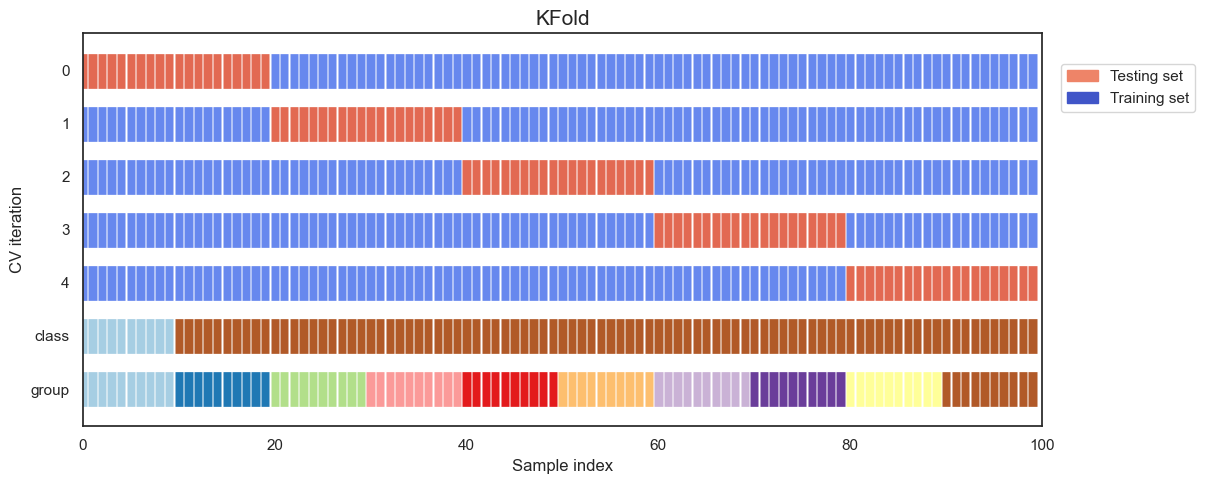

In [92]:
kf = KFold()
X_, y_, groups_ = get_fake_X_y()
plot_cv(KFold, X_, y_, groups_)

### Stratified K-Fold

#### Contexte d'usage

Utilisée par défaut lorsque le modèle est un classificateur et que la variable cible est binaire ou multiclasse.

#### Principe

La méthode Stratified K-Fold maintient le pourcentage d'échantillons pour chaque classe dans tous les folds. Les données des folds d'entraînement et de test sont ainsi équitablement distribuées.

**Exemple** : si le dataset contient 30 % de classe A et 70 % de classe B, chaque fold respectera cette répartition 30/70.

c:\Users\Paul-Emmanuel Buffe\miniconda3\Lib\site-packages\sklearn\model_selection\_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


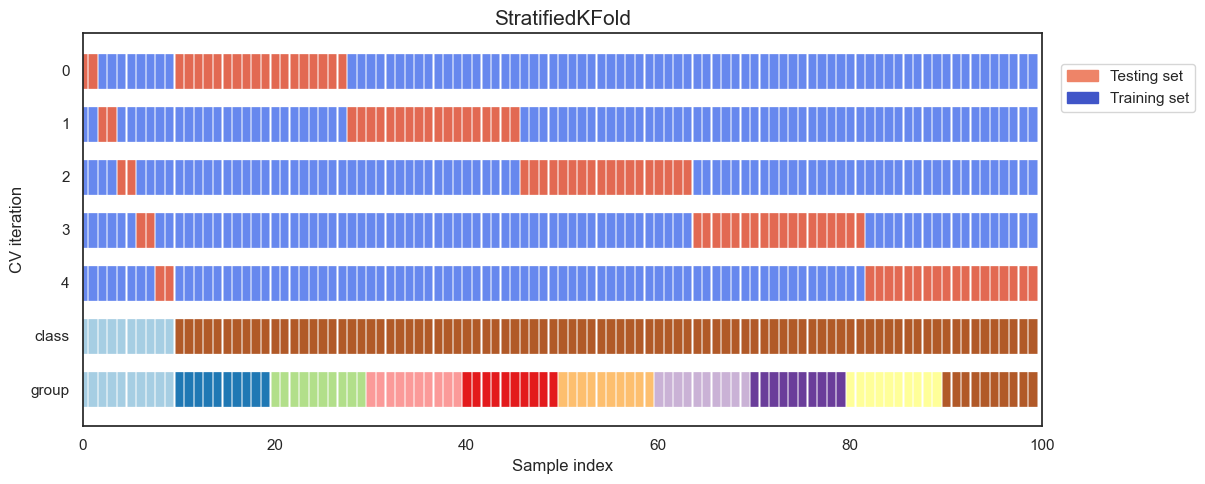

In [93]:
skf = StratifiedKFold()
X_, y_, groups_ = get_fake_X_y()
plot_cv(StratifiedKFold, X_, y_, groups_)

### Group KFold

La méthode **Group KFold** garantit qu'un même groupe n'apparaît jamais à la fois dans l'ensemble d'entraînement et de test au sein d'un même fold.

**Principe** : les données sont divisées en K folds en respectant l'intégrité des groupes. Tous les échantillons appartenant à un même groupe restent ensemble dans le même fold. Cette approche évite la fuite de données (data leakage) qui surviendrait si des observations liées étaient réparties entre train et test.

**Équilibrage** : les folds sont approximativement balancés en nombre de groupes distincts, mais pas nécessairement en nombre d'échantillons total.

**Cas d'usage dans notre contexte** : avec la variable `doctor` comme groupe, chaque patient d'un même médecin reste dans le même fold. Cela simule un scénario réaliste où le modèle doit généraliser à de nouveaux médecins non vus pendant l'entraînement.

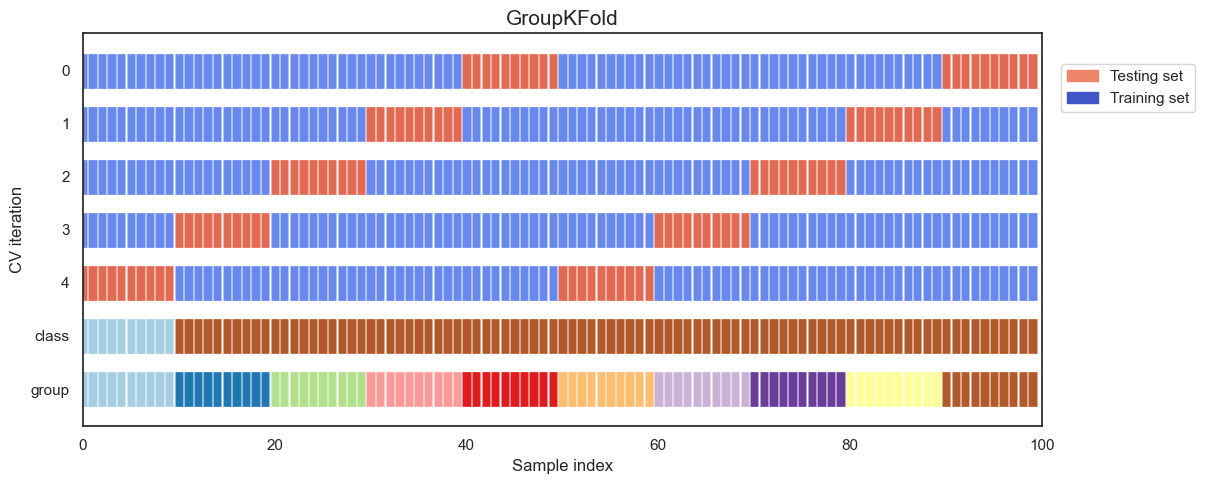

In [94]:
gkf = GroupKFold()
X_, y_, groups_ = get_fake_X_y()
plot_cv(GroupKFold, X_, y_, groups_)

### Stratified Group KFold

La méthode **Stratified Group KFold** combine les avantages de la stratification et du regroupement pour gérer simultanément des classes déséquilibrées et des groupes non-indépendants.

**Principe** : comme Group KFold, cette méthode garantit qu'un même groupe n'apparaît jamais à la fois dans le train et le test. La différence clé réside dans l'objectif d'équilibrage :

- **Group KFold** : équilibre le nombre de groupes distincts dans chaque fold
- **Stratified Group KFold** : préserve la proportion de chaque classe dans chaque fold, tout en respectant la contrainte de non-chevauchement des groupes

**Avantage pour données déséquilibrées** : cette approche est particulièrement adaptée à notre problématique d'AVC où la classe positive (stroke=1) est rare (~5 %). Elle garantit que chaque fold contient approximativement 5 % de cas positifs, évitant ainsi des folds sans aucun cas d'AVC.

**Application** : avec la variable `doctor` comme groupe et `stroke` comme classe cible, cette méthode assure que chaque fold teste la généralisation à de nouveaux médecins tout en maintenant une distribution réaliste des cas d'AVC.

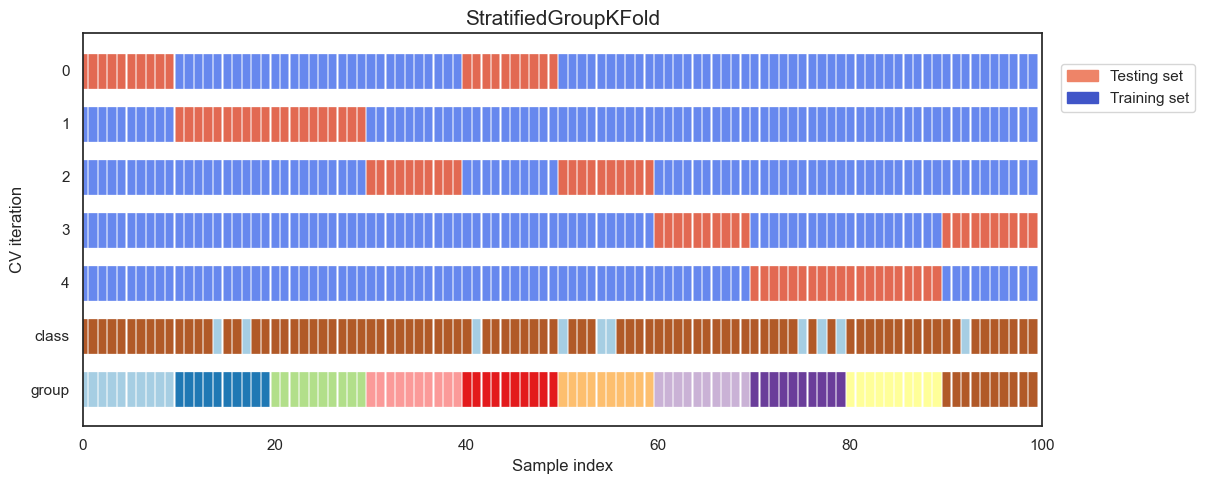

In [95]:
gskf = StratifiedGroupKFold()
X_, y_, groups_ = get_fake_X_y()
np.random.shuffle(y_)
plot_cv(StratifiedGroupKFold, X_, y_, groups_)

### Processus Complet de Validation

#### Étapes

1. **Séparation initiale** : mettre de côté un jeu de test (données jamais vues)
2. **Validation croisée** : sur les données d'entraînement restantes
3. **Sélection du modèle** : choisir le meilleur modèle selon les scores CV
4. **Test final** : évaluer le modèle sélectionné sur le jeu de test mis de côté

#### Résumé
```
Dataset complet
    ↓
[Jeu de test mis de côté] ← Ne pas toucher jusqu'au test final
    ↓
Données d'entraînement
    ↓
K-Folds Cross-Validation
    ↓
Sélection du meilleur modèle
    ↓
Test final sur le jeu de test
```

#### Choix de la méthode de validation croisée

Pour notre cas d'étude, trois contraintes guident le choix de la stratégie :

1. **Données déséquilibrées** : les cas d'AVC représentent ~5 % du dataset, nécessitant une stratification pour préserver cette proportion dans chaque fold.
2. **Structure groupée** : les patients sont liés à des médecins spécifiques (variable `doctor`), créant une dépendance qu'il faut respecter pour éviter le data leakage.
3. **Mélange activé** : le shuffle garantit une randomisation appropriée des groupes entre les folds.

**Solution retenue** : `StratifiedGroupKFold` répond simultanément à ces trois exigences.

In [96]:
# Nous definissons 5 divisions, shuffle pour nous assurer que le trie de nos divisions
# ne jouent aucun rôle dans la manière dont les divisions sont effectuées

sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=529)

X, y, groups = get_X_y(train)

fold = 0
aucs = []

# Itération sur chaque fold généré par StratifiedGroupKFold
for train_idx, val_idx in sgk.split(X, y, groups):
    # Extraction de l'ensemble d'entraînement via les indices train_idx
    X_tr = X.loc[train_idx]
    y_tr = y.loc[train_idx]
    
    # Extraction de l'ensemble de validation via les indices val_idx
    X_val = X.loc[val_idx]
    y_val = y.loc[val_idx]

    # entrainenement du modèle sur le train
    clf = lgb.LGBMClassifier(n_estimators=100)
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_val)
    pred_prob = clf.predict_proba(X_val)[:, 1]
    acc_score = accuracy_score(y_val, pred)
    auc_score = roc_auc_score(y_val, pred_prob)
    print(f"======= Plis{fold} ========")
    print(f'Le score sur le set de Test est accuracy {acc_score:0.4f} et AUC de {auc_score:0.4f}')
    fold += 1
    aucs.append(auc_score)
oof_auc = np.mean(aucs)
print(f'Notre score  AUC score est {oof_auc:0.4f}')

[LightGBM] [Info] Number of positive: 173, number of negative: 3280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 631
[LightGBM] [Info] Number of data points in the train set: 3453, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050101 -> initscore=-2.942307
[LightGBM] [Info] Start training from score -2.942307
======= Plis0 ========
Le score sur le set de Test est accuracy 0.9542 et AUC de 0.8298
[LightGBM] [Info] Number of positive: 189, number of negative: 3824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data

## J. Corrélation linéaire (de Pearson) entre deux variables

## 1. Définition et objectif


- Mesure l'intensité et le sens de la **relation linéaire** entre deux variables quantitatives continues. 
- Permet d’identifier les variables les plus associées à la cible et de détecter la colinéarité entre *features*.


---


## 2. Hypothèses de validité


- Variables continues 
- Relation linéaire 
- Homoscédasticité (variance constante des erreurs) 
- Absence d’outliers 


> La normalité n’est pas strictement nécessaire pour calculer $r$, mais elle est requise pour la p-value.


---


## 3. Fondement mathématique


Le coefficient de corrélation de Pearson $r$ se définit ainsi :


$$
r_{xy} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
= \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$


---


## 4. Interprétation ($r$, $R^2$, p-value)


- $r \in [-1, 1]$ 
- $r=1$ : corrélation positive parfaite 
- $r=-1$ : corrélation négative parfaite 
- $r=0$ : pas de relation linéaire 
- $R^2 = r^2$ : proportion de variance expliquée 
- p-value < 0.05 : corrélation statistiquement significative


---


## 5. Alternatives à Pearson


- Corrélation de **Spearman** (basée sur les rangs) 
- Tau de **Kendall**


---


## 6. DataViz et précautions


- **Corrélation ≠ causalité** 
- Toujours visualiser le nuage de points avant d’interpréter un coefficient 

## K. Une Fonction de Coût

### Introduction

La **fonction de coût** (ou *fonction de perte*, *loss function*) est un élément central en apprentissage automatique. Elle mesure **l'écart entre les prédictions du modèle et les valeurs réelles**.

En résumé : la fonction de coût indique **à quel point le modèle se trompe**. Plus sa valeur est faible, plus le modèle est performant.

---

### Pourquoi est-elle essentielle ?

La fonction de coût permet d'évaluer la qualité d'un modèle, d'ajuster ses paramètres, d'optimiser ses performances et de guider l'algorithme vers la meilleure solution. Elle sert de **boussole mathématique** pendant l'apprentissage.

---

### Principe général

Soit $y$ la valeur réelle et $\hat{y}$ la valeur prédite. L'erreur individuelle est :

$$erreur = y - \hat{y}$$

La fonction de coût agrège ces erreurs sur l'ensemble des données :

$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} L\left(y_i, \hat{y}_i\right)$$

où $J(\theta)$ est la fonction de coût globale, $n$ le nombre d'observations, $L(y_i, \hat{y}_i)$ la fonction de perte pour une observation et $\theta$ les paramètres du modèle.

L'objectif du modèle est de **minimiser la fonction de coût**.

---

### Fonctions de coût en régression

**MSE (Mean Squared Error)**

$$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$

On élève les erreurs au carré puis on fait la moyenne. Très utilisée, elle pénalise fortement les grandes erreurs mais est sensible aux valeurs aberrantes.

**RMSE (Root Mean Squared Error)**

$$RMSE = \sqrt{MSE}$$

Racine carrée du MSE, exprimée dans la même unité que la variable cible.

**MAE (Mean Absolute Error)**

$$MAE = \frac{1}{n} \sum |y - \hat{y}|$$

Moyenne des erreurs absolues, moins sensible aux outliers.

---

### Fonctions de coût en classification

**Log Loss (Binary Cross-Entropy)**, utilisée en classification binaire :

$$Loss = -[y \log(\hat{y}) + (1-y)\log(1-\hat{y})]$$

Elle compare la probabilité prédite à la vraie classe et pénalise fortement les mauvaises prédictions confiantes.

**Categorical Cross-Entropy** : utilisée pour la classification multi-classes.

---

### Optimisation

La minimisation de la fonction de coût se fait via des algorithmes d'optimisation comme la **descente de gradient** (voir section L.).

---

### Interprétation

- Coût faible → bon ajustement
- Coût élevé → modèle imprécis
- Si le coût diminue au fil des itérations → apprentissage correct
- Si le coût train diminue mais le coût validation augmente → surapprentissage probable

---

### Conclusion

La fonction de coût est le cœur mathématique de l'apprentissage automatique. Elle permet d'évaluer l'erreur du modèle, de guider l'optimisation, de comparer différents modèles et d'assurer une bonne généralisation. Un modèle performant est un modèle qui **minimise correctement sa fonction de coût tout en restant généralisable**.

## L. La Descente de Gradient

La descente de gradient est un algorithme d'optimisation couramment utilisé pour entraîner les modèles de machine learning. Son objectif est de réduire l'erreur entre les valeurs prédites par le modèle et les valeurs réelles.

Lors de l'entraînement, le modèle ajuste progressivement ses paramètres à partir des données d'apprentissage. La fonction de coût agit comme un indicateur de performance en mesurant l'erreur à chaque itération. Tant que cette erreur n'est pas proche de zéro, le modèle continue d'apprendre.

La descente de gradient fonctionne de manière similaire à la recherche d'une droite de meilleur ajustement, en minimisant l'erreur quadratique moyenne entre les valeurs réelles et les valeurs prédites. Elle repose généralement sur une fonction convexe, facilitant la convergence.

Les calculs successifs de dérivées partielles permettent à l'algorithme de se rapprocher progressivement du minimum local ou global, appelé point de convergence.

---

### Taux d'apprentissage (alpha)

Le taux d'apprentissage, noté $\alpha$, correspond à la taille des pas effectués pour atteindre le minimum de la fonction de coût.

- Un taux élevé permet une convergence plus rapide, mais comporte un risque de dépassement du minimum.
- Un taux faible améliore la précision, mais rend l'apprentissage plus lent et plus coûteux en calcul.

---

### Fonction mathématique

On cherche à minimiser la fonction de coût :

$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Avec :
- $y_i$ : valeur réelle
- $\hat{y}_i$ : valeur prédite par le modèle
- $n$ : nombre d'observations
- $J(\theta)$ : erreur globale du modèle

Plus la valeur de $J(\theta)$ est faible, plus le modèle est performant.

### Règle de mise à jour des paramètres

L'objectif est de modifier progressivement les paramètres du modèle, notés $\theta$, afin de réduire l'erreur. Pour cela, on utilise la pente de la fonction de coût, appelée gradient.

$$\theta \leftarrow \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}$$

Dans cette équation :
- $\theta$ représente les paramètres du modèle
- $\alpha$ est le taux d'apprentissage
- $\frac{\partial J(\theta)}{\partial \theta}$ indique la direction de la plus forte augmentation de l'erreur

La soustraction du gradient permet de se déplacer vers le minimum de la fonction de coût.

### Implémentation

In [97]:
# Génération des données 
# 100 point suivant la relation y= 3X + 7 (ligne droite) + bruit
# Objectif : Le modèle doit retrouver poids ≈ 3 et biais ≈ 7

np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 3 * X + 7 + np.random.randn(100) * 2

print(y)

[ 7.99342831  7.0265017   8.90143768 10.95515062  7.74381446  8.0468776
 11.97660745 10.65608158  8.48529365 10.81239281  9.10346764  9.40187383
 11.12028818  7.11283345  7.79258858 10.42087949  9.82282261 12.78000982
 10.6384973   9.93296835 15.9919036  12.91208376 13.80172308 11.1202006
 13.18396182 14.79760276 12.57680072 15.93321422 14.28357111 15.20449129
 14.88749587 20.09849576 16.66997525 14.88457814 18.94812013 15.16437331
 18.3268181  14.29278096 15.85877942 19.21190429 20.59814528 19.76697899
 19.49597616 19.42809564 17.37628935 19.19667522 20.0181164  23.35666869
 22.23269112 18.32240454 22.79968309 21.68438089 21.40373176 24.28395864
 25.42563541 25.5292269  22.29126192 23.65430252 25.23828444 26.82987813
 24.22346971 25.11353053 23.57520884 23.69849584 28.01899104 29.40944975
 26.85597976 29.3100961  28.32933266 26.6188514  28.93491242 31.59122465
 28.74652974 32.25049943 24.18475222 31.37107774 30.20439717 29.73531863
 30.81988519 26.96425611 30.80308047 32.25967969 34.8

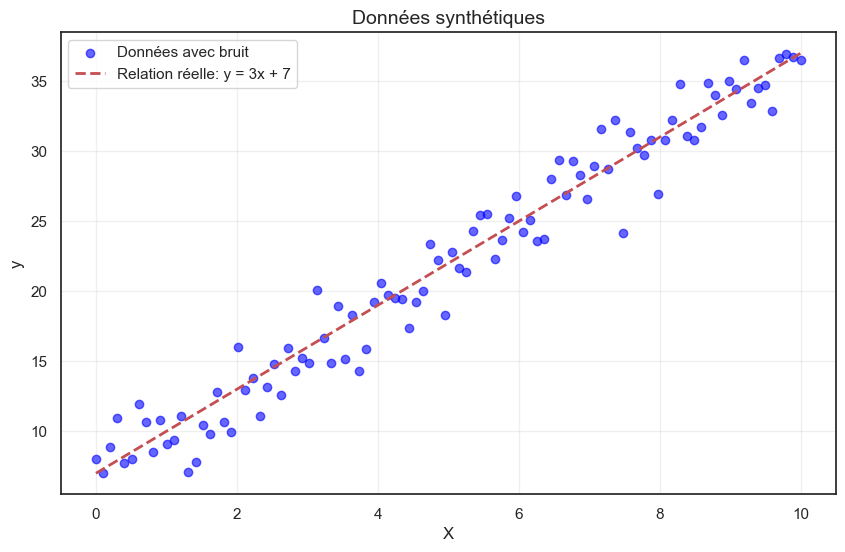

In [98]:
# Visualisation  des points
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', label='Données avec bruit')
plt.plot(X, 3 * X + 7, 'r--', linewidth=2, label='Relation réelle: y = 3x + 7')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Données synthétiques', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


In [99]:
# Définition des hyperparamètres

taux_aprrentissage = 0.01 # taille du pas / mise à jour
taille_lot = 20 # nb exemples / batch
nb_epoques = 500 # nb maximum d'époques
seuil_variation = 0.001 # critère d'arrêt par convergence

# Initialisation des paramètres
# notre modèle commence avec une droite complètement fausse (y = 0x + 0)

poids = 0.0
biais = 0.0

# Historique (visualisation)
historique_perte = []
historique_visu_console = []
perte_precedente = float('inf')

# Boucle d'entraînement (traitement par mini-batch)
# Découpage des données en lots de 20 exemples = 5 itérations par époque

for epoque in range(nb_epoques):
    perte_totale = 0
    for i in range (0, len(X), taille_lot):
        X_batch = X[i:i+taille_lot]
        y_batch = y[i:i+taille_lot]

        # Les étapes de la descente de gradient
        # Prédictions
        predictions = poids * X_batch + biais

        # Calcul de la perte
        erreur = predictions - y_batch
        perte = np.mean(erreur ** 2) # MSE
        perte_totale += float(perte)

        # Calcul des gradients (direction de la pente)
        gradient_poids = np.mean(2 * erreur * X_batch)
        gradient_biais = np.mean(2 * erreur)
        # gradient + => il faut diminuer le paramêtre
        # gadient - => il faut augmenter le paramêtre

        # Mise à jour des paramêtres
        # Le signe - assure que l'on va toujours dans la direction opposé au gradient
        poids -= taux_aprrentissage * gradient_poids
        biais -= taux_aprrentissage * gradient_biais

    historique_visu_console.append(perte_totale)
    
    # Critère d'arrêt : variation négligeable
    variation = abs(perte_precedente - perte_totale)
    if variation < seuil_variation:
        print(f"✓ Convergence atteinte à l'époque {epoque+1}")
        break
    perte_precedente = perte_totale

# Affichage par tranche de 10 époques
for epoque, perte in enumerate(historique_visu_console):
    if (epoque + 1) % 10 == 0 or epoque == 0 or epoque == len(historique_visu_console) - 1:
        print(f"Époque {epoque+1:2d} | Perte: {perte:.3f}")

print(f"\nNombre d'époques effectuées : {len(historique_visu_console)}")

✓ Convergence atteinte à l'époque 138
Époque  1 | Perte: 653.752
Époque 10 | Perte: 47.707
Époque 20 | Perte: 34.462
Époque 30 | Perte: 26.782
Époque 40 | Perte: 22.336
Époque 50 | Perte: 19.769
Époque 60 | Perte: 18.291
Époque 70 | Perte: 17.444
Époque 80 | Perte: 16.960
Époque 90 | Perte: 16.687
Époque 100 | Perte: 16.534
Époque 110 | Perte: 16.450
Époque 120 | Perte: 16.404
Époque 130 | Perte: 16.380
Époque 138 | Perte: 16.370

Nombre d'époques effectuées : 138


#### Droite de régression finale

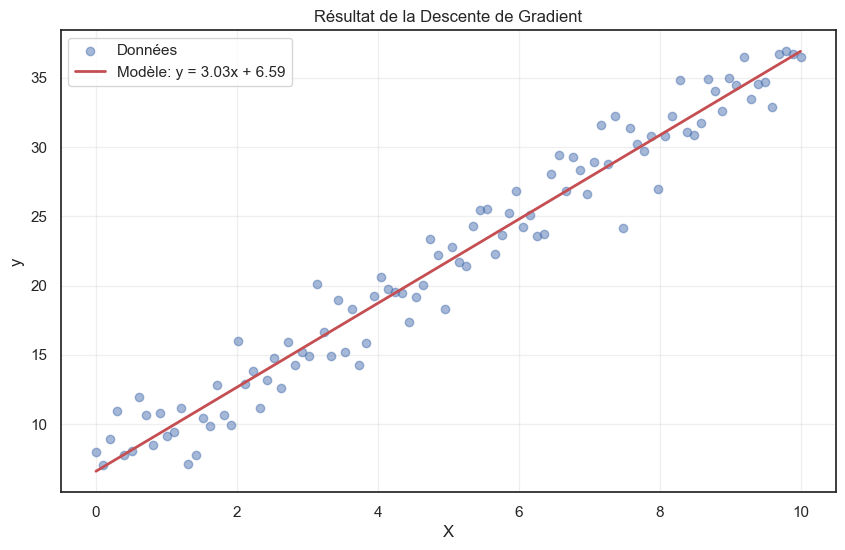

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Données')
plt.plot(X, poids * X + biais, 'r-', linewidth=2, 
         label=f'Modèle: y = {poids:.2f}x + {biais:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Résultat de la Descente de Gradient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



#### Evolution de la perte

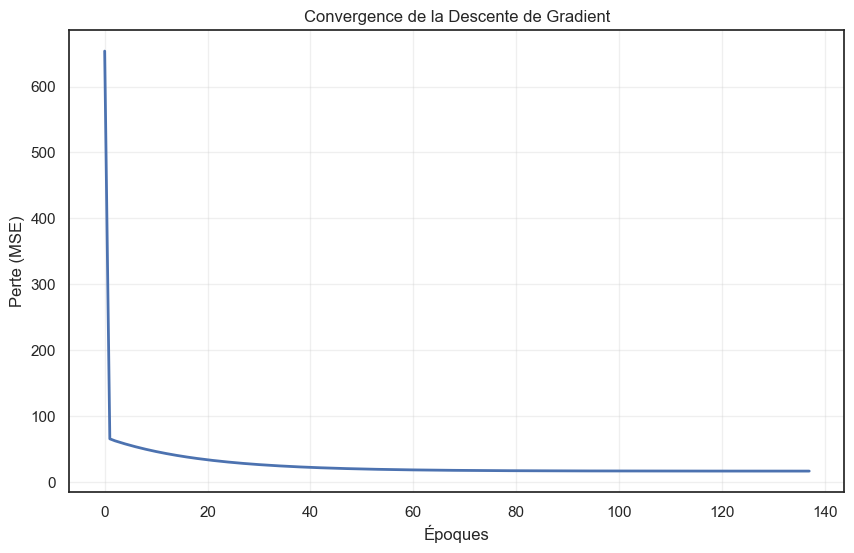


Paramètres finaux : poids = 3.03, biais = 6.59
Valeurs réelles : poids = 3.00, biais = 7.00


In [101]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(historique_visu_console)), historique_visu_console, 'b-', linewidth=2)
plt.xlabel('Époques')
plt.ylabel('Perte (MSE)')
plt.title('Convergence de la Descente de Gradient')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nParamètres finaux : poids = {poids:.2f}, biais = {biais:.2f}")
print(f"Valeurs réelles : poids = 3.00, biais = 7.00")

### Intuition visuelle

La descente de gradient peut être comparée à une marche sur une colline. Le point de départ correspond à une erreur élevée, et chaque pas, guidé par la pente, rapproche progressivement du point le plus bas où l'erreur est minimale.

---

### Condition d'arrêt

L'algorithme s'arrête lorsque l'erreur devient très faible ou lorsque les mises à jour des paramètres deviennent négligeables.